# Day 022 · 订单簿基础
**Order Book 101** · 阶段 P1 · 量化基础

> 订单簿是真实交易所的核心数据结构 — 买卖双方的限价单按价格 / 时间排队,撮合引擎从价格最高的买单和价格最低的卖单开始撮合。这一节我们做三件事:① 把限价单簿 LOB 的数据结构从头建出来,看清买盘 / 卖盘 / 最佳买卖价 BBO / 队列深度怎么组织;② 用 numpy 模拟一千个订单(限价 / 市价 / 撤单)的到达和撮合过程,记录 BBO 演化曲线和买卖盘失衡 OFI 指标;③ 看清楚『限价单提供流动性』『市价单消耗流动性』这条市场微结构的第一性原理。这是从公式走向真实交易场景的第一步,也是高频做市策略和最小冲击成本算法的基础。

---

**课件生成日期:** 2026-05-16  ·  **建议学习时长:** 18 分钟

学习路径建议:1)先看视频建立直觉 → 2)阅读本 notebook 跑代码 → 3)看 PDF 课件复习要点 → 4)做自测题

## 🔧 第一步:环境自检 + 自动安装

**第一次拿到这份 notebook,请先运行下面这一格。** 它会:
1. 检查所有需要的 Python 包,缺什么自动 `pip install` 装上
2. 注入中文字体到 matplotlib(让图标不出乱码)
3. 跑完看到 `✓ 环境就绪` 就可以继续下面的代码

> 这一格只在第一次跑要等几十秒,后面再开 notebook 就秒过。

In [1]:
# === 环境自检 + 自动安装(运行此单元格即可) ===
# 检测缺失的库 → 自动 pip 安装 → 注入中文字体 → 一行命令搞定
import importlib
import subprocess
import sys
import os

REQUIRED = ["matplotlib", "numpy", "numpy_financial", "pandas", "scipy", "sklearn", "statsmodels", "yfinance"]
PIP_NAME = {
    "sklearn": "scikit-learn",
    "cv2": "opencv-python",
    "PIL": "Pillow",
    "bs4": "beautifulsoup4",
    "yaml": "PyYAML",
}

missing = []
for mod in REQUIRED:
    try:
        importlib.import_module(mod)
    except ImportError:
        missing.append(PIP_NAME.get(mod, mod))

if missing:
    print(f"⏳ 缺少 {len(missing)} 个包,正在自动安装:{missing}")
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *missing])
    print("✓ 安装完成")
else:
    print(f"✓ 所有 {len(REQUIRED)} 个必需库已就绪")

# === 中文字体配置(让 matplotlib 不出乱码) ===
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

CJK_FONT_PATHS = [
    "/usr/share/fonts/opentype/noto/NotoSansCJK-Regular.ttc",  # Linux/WSL
    "C:/Windows/Fonts/msyh.ttc",                               # Windows 微软雅黑
    "C:/Windows/Fonts/simhei.ttf",                             # Windows 黑体
    "/System/Library/Fonts/PingFang.ttc",                      # macOS 苹方
    "/System/Library/Fonts/STHeiti Medium.ttc",                # macOS 黑体
]
for p in CJK_FONT_PATHS:
    if os.path.exists(p):
        fm.fontManager.addfont(p)
        print(f"✓ 中文字体已加载:{os.path.basename(p)}")
        break
plt.rcParams["font.sans-serif"] = ["Noto Sans CJK JP", "Microsoft YaHei",
                                    "PingFang SC", "SimHei", "DejaVu Sans"]
plt.rcParams["axes.unicode_minus"] = False
print("✓ 环境就绪 — 现在可以跑下面的代码单元格")


✓ 所有 8 个必需库已就绪
✓ 中文字体已加载:NotoSansCJK-Regular.ttc
✓ 环境就绪 — 现在可以跑下面的代码单元格


## 学习目标

- 看懂限价单簿 LOB 的核心数据结构 — 买盘 / 卖盘 / 价格档位 / 队列深度
- 区分限价单(LO)和市价单(MO),理解『LO 提供流动性 / MO 消耗流动性』的双边角色
- 理解价格优先 + 时间优先两条撮合规则,知道为什么排队位置决定成交概率
- 用 numpy 模拟 LOB 动态演化,画出 BBO 演化曲线 + 买卖盘深度热力图 + OFI 时间序列
- 看懂买卖盘失衡 OFI 是短期价格变动的领先指标,这是高频做市的核心信号源

## 历史背景:订单簿 1971-2007 — 从纸张到光速撮合的三十六年

订单簿不是凭空发明的,而是市场撮合机制电子化过程中自然演化出的数据结构。一九七一年之前,纽交所 NYSE 用『专家做市商』specialist 制度,所有订单交到一个人手里(就是叫 specialist 的那个人),由他用纸笔记录、撮合、报价。

转折点是一九七一年。NASDAQ(National Association of Securities Dealers Automated Quotations)上线 — 这是第一个完全电子化的报价系统,虽然撮合仍由 dealer 完成,但所有报价进入计算机集中显示。订单簿从纸面走到屏幕。

第二个转折点是一九九六年的 Island ECN。这是第一个公开 limit order book 给所有交易者看的电子撮合平台 — 任何人都能看到买卖盘各档的真实深度,而不只是 BBO。Island 后来被 INET 收购,再被 NASDAQ 收购,『公开订单簿 + 价格-时间优先撮合』成为美股标准。

第三个转折点是二零零七年 Reg NMS(Regulation National Market System)— SEC 强制规定所有美股订单必须 route 到全市场 BBO,导致 venue 碎片化 + HFT 在不同 venue 之间抢套利。订单簿从『一个交易所一本』变成『十几个交易所各一本 + 必须汇总成 NBBO』。

这三十六年的演化告诉你一件事:订单簿不是孤立的数据结构,而是『流动性怎么被组织、被发现、被竞争』的载体。看懂订单簿就能看懂市场参与者的行为意图 — 谁在挂单(做市商) / 谁在吃单(主动方) / 谁在撤单(虚晃) / 谁的单挂得最长(耐心资金)。这是从『看 K 线』走向『看市场内在结构』的关键认知。



## 核心概念

下面每一节是听完视频后回头细读的内容。

### 1. 限价单 LO vs 市价单 MO — 流动性的两面

**定义**:限价单 LO 指定『最多愿意以多少钱买 / 最少愿意以多少钱卖』,如果当前没人接受这个价就挂进订单簿排队等待。市价单 MO 不指定价格,以当前可成交的最优价立刻成交。

**经济角色**:
- LO 提供流动性 — 它在订单簿里等着,给别人提供成交机会
- MO 消耗流动性 — 它从订单簿里吃走一档或多档对手盘

**身份不对称**:你挂 LO 你是做市商 / 给市场提供深度;你下 MO 你是主动方 / 急着成交。交易所对这两种角色收费不同 — 多数交易所给 LO 返佣(maker rebate),给 MO 收费(taker fee),目的是激励大家挂 LO 增加深度。

**典型场景**:
- 你看 1 万股,想要立刻成交不在乎几分钱差价 → MO
- 你看 10 万股,想要均价更好不急着成交 → 拆成多个 LO 分批挂
- 高频做市商每秒挂数千个 LO 在 BBO 附近 → 赚买卖价差 spread

**散户陷阱**:多数散户默认下 MO(操作简单),不知道在流动性差的票上 MO 会瞬间吃穿好几档,实际成交价比看到的 BBO 差很多。这就是冲击成本,第 23 课会专门讲。

```
LO 状态机:挂单 → 排队 → 成交或撤单 / MO 状态机:发单 → 立刻吃单 → 完成
```

> **举例:** 假设茅台 BBO 是买一一千八百价格 100 股 / 卖一一千八百一价格 200 股。你下市价单买一千股 → 先吃卖一的 200 股一千八百一,再吃卖二、卖三...直到一千股吃完,实际均价可能 1801.5 元。同等情况下你挂限价买单 1800 元一千股 → 排在买一队列后面等卖方下来成交,可能等几小时也可能不成。


### 2. 最佳买卖价 BBO + 中间价 + 价差 spread

**BBO** 即 Best Bid Offer — 订单簿当前最高买价(best bid)和最低卖价(best offer / best ask)。这是市场对该标的『公允价格』的瞬时共识。

**核心定义**:
- mid price = (best bid + best ask) / 2
- spread = best ask - best bid
- spread_bps = spread / mid × 10000(用 basis point 表示)

**spread 的经济含义**:这是做市商挂单的安全边际。spread 越宽,挂 LO 的人补偿越多;spread 越窄,意味着该标的流动性越好,竞争越激烈。

**spread 的现实区间**:
- 美股大盘(AAPL / SPY):spread ≈ 1 美分,千分之一 / 万分之零点几
- 美股小盘 / 国内 ST:spread ≈ 几分到几毛 / 万分之十以上
- A 股活跃白马(茅台 / 平安):spread ≈ 一两个最小变动价位
- 港股不活跃股:spread 可达几个百分点
- 加密 BTC / USDT(币安主板):spread ≈ 1 美元 / 1 BTC 上,即 0.001%
- 加密小币种 spread 经常 1% 以上

**实战用法**:你想知道一只票好不好交易,看 spread_bps 比看价格本身更重要。spread_bps < 5(万分之五)= 高流动性可大笔进出;spread_bps > 50(千分之五)= 流动性差,大单进出会冲击。

```
spread = ask - bid / spread_bps = (spread / mid) × 10000 / mid = (bid+ask)/2
```

> **举例:** 假设比亚迪 BBO 是买一 230.50 卖一 230.55,mid = 230.525,spread = 0.05 元,spread_bps = 0.05 / 230.525 × 10000 ≈ 2.17。表示流动性中上,5 万元以内可一次性下单。如果是某个小盘股 BBO 买一 20.00 卖一 20.20,spread_bps = 100,流动性极差,5 万元下单可能直接吃穿到 20.50。


### 3. 价格优先 + 时间优先 — 撮合的两条铁律

**撮合规则**(几乎所有现代交易所通用):

**Rule 1 — 价格优先**:买盘价格越高排越前,卖盘价格越低排越前。这保证『谁出价好谁先成交』的市场效率。

**Rule 2 — 时间优先(在同一价格档内)**:先挂的单排在队列前面,后挂的排后面。同一档内成交按 FIFO(先进先出)顺序。

**为什么排队位置重要**:
- 排在 BBO 队列最前面 → 下一个 MO 来就成交,赚 spread
- 排在 BBO 队列尾部 → 可能等十几个 MO 都没轮到你,期间价格走开你就废了

**高频做市的核心 edge**:抢到 BBO 队列最前面位置(rank=1)。为此 HFT 投资天量算力 + 直连机房(co-location)在交易所边上 + 用 FPGA 在微秒级别撮合订单,目的就是把限价单挂到 BBO 队列最前。

**散户的影响**:你挂限价单时,如果当前 BBO 已经有人挂了同样价格,你只能排到队尾。这意味着即使价格合适,你的成交概率也低很多。所以专业的人会在 BBO 内侧再加一档(price improvement),用更好的价格抢到 rank=1。

**特殊撮合规则**:个别市场用 pro-rata(按比例分配)代替时间优先 — 比如某些期货合约。但 99% 的现货市场用价格-时间优先。

```
排队 rank = 同价格档内时间到达顺序 / 价格档内『成交概率』近似 ∝ 1 / rank
```

> **举例:** 假设当前买一 1000 元有 5 个 LO 在排队:A 挂 100 股 / B 挂 200 股 / C 挂 100 股 / D 挂 300 股 / E 挂 100 股。来一个市价卖单 500 股 → 先吃 A 全部 100 股、B 全部 200 股、C 全部 100 股、D 部分 100 股。E 完全没动。下一个市价卖单来再继续吃 D 剩余 200 股、E 100 股。如果中间 BBO 跌到 999,买一变成新价格,1000 这档剩下的 LO 全部失效(或被 cancel),E 永远等不到成交。


### 4. 深度 depth + 买卖盘热力图

**深度**指订单簿在各档位上累积的挂单量。深度越厚,大单进入消化能力越强,价格冲击越小。

**累积深度**(cumulative depth):从 BBO 开始一档一档往里累加挂单量,得到一个『价格 vs 累积成交量』的曲线。这条曲线告诉你『要吃多少量才能把价格推到 X 元』。

**热力图可视化**:横轴价格档位,纵轴时间,颜色深浅表示挂单量。看几秒到几分钟的快照,你能看到:
- 静态做市商:每档稳定挂大量(几千股每档)
- 散户单:随机出现,数量小(几十到几百股)
- iceberg(冰山单):显示量小但实际隐藏量大,成交后立刻补上
- 撤单密集区:某些挂单只显示几秒就撤,叫 flickering quote,典型的 HFT 行为

**深度与流动性的关系**:
- BBO 1-2 档累积深度高 → 小单进出无冲击
- BBO 5 档以内累积深度高 → 中等单可吸收
- BBO 10 档以内深度低 → 大单进入会大幅推动价格

**散户用法**:下单前看一下 5 档行情,估算你的单量能不能在前 2 档消化。如果不能,要么拆单分批,要么改用 algo order(VWAP / TWAP)。

```
cumulative_depth(p) = Σ qty[bid] for all bid ≥ p (买盘) or ask ≤ p (卖盘)
```

> **举例:** 你看到 BBO 买一 100 元 200 股 / 买二 99.99 元 500 股 / 买三 99.98 元 300 股。你想卖 800 股,累积深度告诉你:卖前 200 股成交 100 元,接下来 500 股成交 99.99 元,最后 100 股成交 99.98 元,均价 99.99 元。如果只看 BBO 100 元,你可能误以为能全部按 100 元卖出 — 实际差了 0.01-0.02 元就是冲击成本。


### 5. 买卖盘失衡 OFI — 短期价格的领先指标

**Order Flow Imbalance**(OFI):衡量某段时间内买盘订单流和卖盘订单流的净差额。是高频做市和短期方向预测的核心信号。

**最简定义**:OFI = (买入市价单总量 - 卖出市价单总量) / 总量。范围 [-1, +1]。

- **OFI > 0**: 主动买盘强,接下来一段时间价格大概率走高
- **OFI < 0**: 主动卖盘强,接下来一段时间价格大概率走低
- **OFI ≈ 0**: 供需平衡,价格震荡

**经济直觉**:市价单代表交易者『不在乎价格,我要立刻成交』的强烈意图。如果短时间内市价买单大幅多于市价卖单,说明买方更急迫,卖方报价会被吃穿好几档,价格自然推高。

**短期预测能力**:实证研究显示,OFI 对未来 1-30 秒的价格变动有显著解释力(R² 在 0.2-0.4)。高频策略基于 OFI 信号做高频做市的方向调整 — OFI 转负时把买盘 LO 撤掉、把卖盘 LO 加厚,避免被吃单。

**散户用法**:
- 实盘交易时看 5 档行情的『大单方向』可粗略估计 OFI
- 看到买盘大单连续吃卖盘 5 档以上 = OFI 强正,短期可能继续走高,可以追入
- 看到卖盘大单连续吃买盘 5 档 = OFI 强负,短期可能继续跌,可以等回调
- 但要注意 OFI 信号衰减很快(秒级),散户实盘很难做到

**注意陷阱**:大单不一定是真实意图,可能是 iceberg 或 spoofing(虚假大单引诱跟风后立刻撤)。专业 HFT 会过滤这些噪音,散户难以辨别。

```
OFI_t = (买入 MO 量 - 卖出 MO 量) / (买入 MO 量 + 卖出 MO 量) ∈ [-1, +1]
```

> **举例:** 过去 10 秒钟标的 X 有 30 笔市价买单成交 5000 股、20 笔市价卖单成交 2000 股。OFI = (5000 - 2000) / 7000 ≈ +0.43。OFI 强正,接下来 30 秒价格大概率走高 1-2 个 spread。


## 实操:合成订单簿 LOB + 撮合引擎 + BBO 演化 + OFI 时间序列

下面这段代码跟视频里讲解的 highlights 是一致的,可以**直接 Run All** 看结果。

**依赖安装:**
```bash
pip install pandas numpy matplotlib yfinance akshare statsmodels
```


初始 BBO 买一 99.99 卖一 100.01 spread 0.0200
初始 mid 100.0000 · 5 档买盘深度 2150 卖盘深度 2965

模拟结束:
  总成交笔数 1248
  买入 MO 累计 87099 股 / 卖出 MO 累计 99166 股
  最终 BBO 买一 100.00 卖一 100.01
  mid 从 100.00 走到 100.0050 (漂移 0.0050 = 0.5 ticks)
  平均 spread 0.0193 中位 0.0100
  OFI(过去30) vs 未来30 mid 变动相关性 0.081
图已保存 chart_01.png


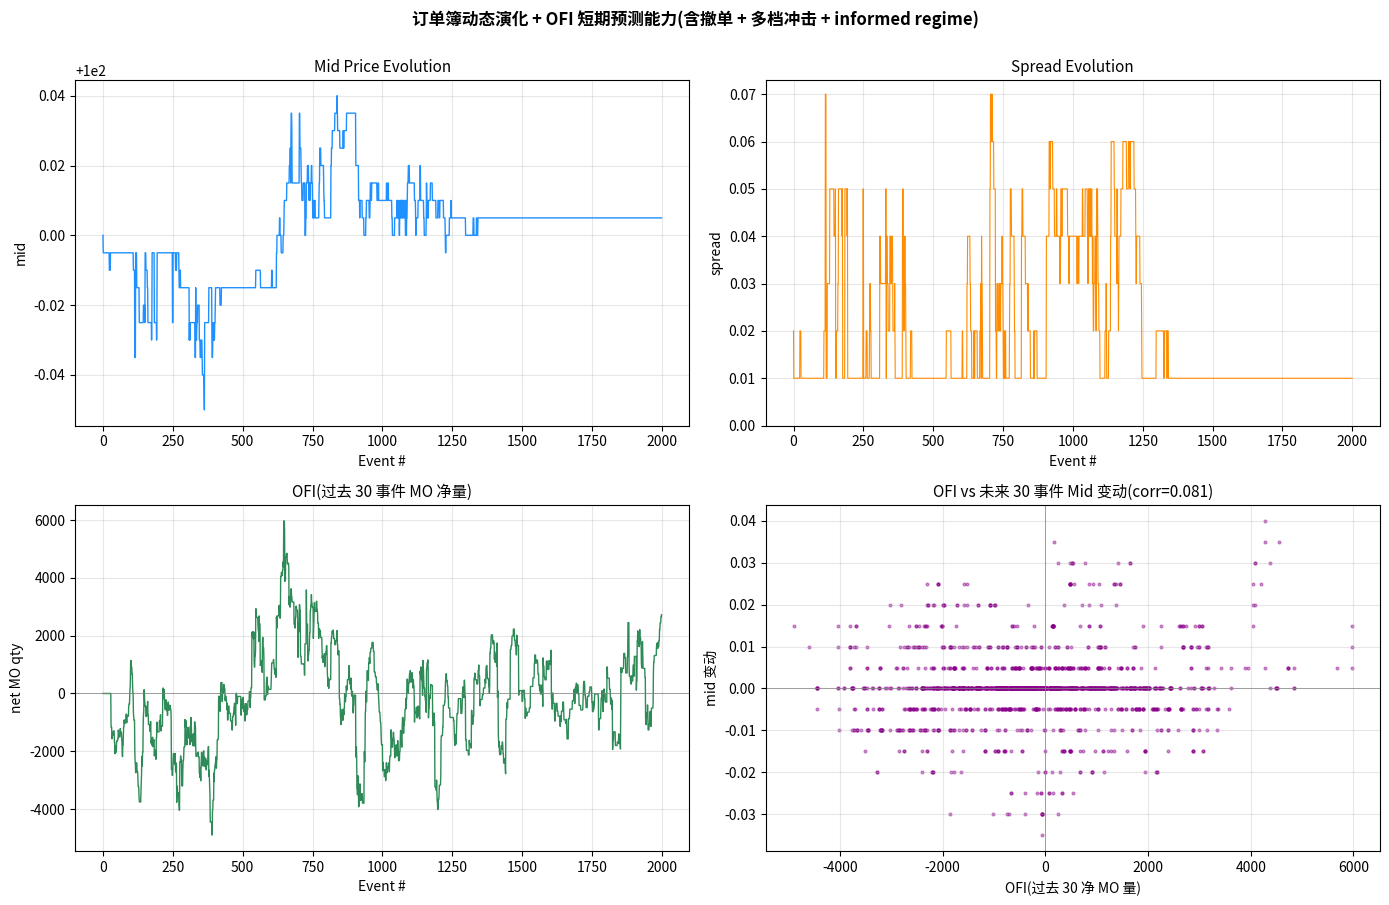

In [2]:
# day_022_order_book.py — 订单簿 + 撮合 + 撤单 + 多档冲击 + OFI 预测能力实测
import numpy as np
import matplotlib.pyplot as plt
from collections import deque
np.random.seed(42)

# ============ 1. LOB 数据结构 ============
class OrderBook:
    """限价单簿:dict[price -> deque(qty, oid)] 维护两边,支持加单/撤单/市价吃单"""
    def __init__(self, tick=0.01):
        self.bids = {}; self.asks = {}; self.tick = tick
        self.next_oid = 0; self.trades = []
        self.orders = {}  # oid -> (side, price)  撤单时按 oid 找回
    def best_bid(self): return max(self.bids.keys()) if self.bids else None
    def best_ask(self): return min(self.asks.keys()) if self.asks else None
    def mid(self):
        bb, ba = self.best_bid(), self.best_ask()
        return (bb + ba) / 2 if bb and ba else None
    def spread(self):
        bb, ba = self.best_bid(), self.best_ask()
        return (ba - bb) if bb and ba else None
    def depth(self, side, n_levels=5):
        """返回 best 起 n 档累积深度"""
        book = self.bids if side == 'B' else self.asks
        prices = sorted(book.keys(), reverse=(side == 'B'))[:n_levels]
        return sum(sum(q for q, _ in book[p]) for p in prices)
    def add_limit(self, side, price, qty, ts):
        # crossed book 守卫:若 LO 价跨过对面 best,改为市价单吃单
        if side == 'B' and self.best_ask() is not None and price >= self.best_ask():
            filled, _ = self.match_market('B', qty, ts); return None
        if side == 'S' and self.best_bid() is not None and price <= self.best_bid():
            filled, _ = self.match_market('S', qty, ts); return None
        book = self.bids if side == 'B' else self.asks
        if price not in book: book[price] = deque()
        oid = self.next_oid; self.next_oid += 1
        book[price].append((qty, oid))
        self.orders[oid] = (side, price)
        return oid
    def cancel_random(self, side):
        """随机撤一个挂单(偏向靠 best 的档位 — 真实做市撤单也偏 BBO)"""
        book = self.bids if side == 'B' else self.asks
        if not book: return False
        # 按距 best 远近 weighted 抽档位
        best = self.best_bid() if side == 'B' else self.best_ask()
        prices = sorted(book.keys(), reverse=(side == 'B'))
        weights = np.array([1.0 / (abs(p - best) / self.tick + 1) for p in prices])
        weights /= weights.sum()
        p = np.random.choice(prices, p=weights)
        queue = book[p]
        if not queue: return False
        # 撤队列里随机一单
        idx = np.random.randint(len(queue))
        q, oid = queue[idx]
        del queue[idx]
        if oid in self.orders: del self.orders[oid]
        if not queue: del book[p]
        return True
    def match_market(self, side, qty, ts):
        """side='B' 市价买吃卖盘 / 'S' 市价卖吃买盘。多档冲击 — 一直吃到 qty 用完"""
        opposite = self.asks if side == 'B' else self.bids
        prices = sorted(opposite.keys()) if side == 'B' else sorted(opposite.keys(), reverse=True)
        filled = 0; vwap_sum = 0
        for p in list(prices):
            queue = opposite[p]
            while queue and filled < qty:
                q, oid = queue[0]
                take = min(q, qty - filled)
                filled += take; vwap_sum += take * p
                self.trades.append((ts, p, take, side))
                if take == q:
                    queue.popleft()
                    if oid in self.orders: del self.orders[oid]
                else:
                    queue[0] = (q - take, oid)
            if not queue: del opposite[p]
            if filled >= qty: break
        return filled, (vwap_sum / filled if filled > 0 else None)

# ============ 2. 初始化 LOB(10 档每档深度 200-800)============
lob = OrderBook(tick=0.01)
init_mid = 100.00
for i in range(10):
    bid_price = round(init_mid - 0.01 * (i + 1), 2)
    ask_price = round(init_mid + 0.01 * (i + 1), 2)
    lob.add_limit('B', bid_price, int(np.random.uniform(200, 800)), 0)
    lob.add_limit('S', ask_price, int(np.random.uniform(200, 800)), 0)
print(f'初始 BBO 买一 {lob.best_bid():.2f} 卖一 {lob.best_ask():.2f} spread {lob.spread():.4f}')
print(f'初始 mid {lob.mid():.4f} · 5 档买盘深度 {lob.depth("B",5)} 卖盘深度 {lob.depth("S",5)}')

# ============ 3. 模拟订单流(LO + MO + Cancel + 大 MO + informed regime)============
N_EVENTS = 2000
mid_series, spread_series, ofi_inst = [], [], []
buy_mo_tot = sell_mo_tot = 0
# 默认平衡 regime
regime = 'bal'; event_probs = [0.30, 0.30, 0.12, 0.12, 0.08, 0.08]   # LO_B/LO_S/MO_B/MO_S/Cancel_B/Cancel_S

for t in range(N_EVENTS):
    # 每 200 事件切 regime — 模拟 informed flow / 大资金进出场
    if t % 200 == 0:
        regime = np.random.choice(['bull', 'bear', 'bal'], p=[0.35, 0.35, 0.30])
        if   regime == 'bull': event_probs = [0.25, 0.25, 0.22, 0.08, 0.10, 0.10]   # MO_buy 强
        elif regime == 'bear': event_probs = [0.25, 0.25, 0.08, 0.22, 0.10, 0.10]   # MO_sell 强
        else:                  event_probs = [0.30, 0.30, 0.12, 0.12, 0.08, 0.08]
    event = np.random.choice(['LO_B', 'LO_S', 'MO_B', 'MO_S', 'CX_B', 'CX_S'], p=event_probs)
    mo_buy_qty = mo_sell_qty = 0

    if event == 'LO_B':
        # 70% 同价补 best, 30% improve(clamp 不跨价)
        bb = lob.best_bid(); ba = lob.best_ask() or init_mid
        if bb is None: price = round(ba - 0.01, 2)
        elif np.random.rand() < 0.7: price = bb
        else: price = min(round(bb + 0.01, 2), round(ba - 0.01, 2))
        lob.add_limit('B', price, int(np.random.uniform(100, 400)), t)
    elif event == 'LO_S':
        ba = lob.best_ask(); bb = lob.best_bid() or init_mid
        if ba is None: price = round(bb + 0.01, 2)
        elif np.random.rand() < 0.7: price = ba
        else: price = max(round(ba - 0.01, 2), round(bb + 0.01, 2))
        lob.add_limit('S', price, int(np.random.uniform(100, 400)), t)
    elif event == 'MO_B':
        # 90% 普通单(100-400),10% 大单 institutional flow (500-2000) 吃多档
        if np.random.rand() < 0.10: qty = int(np.random.uniform(500, 2000))
        else:                       qty = int(np.random.uniform(100, 400))
        filled, _ = lob.match_market('B', qty, t)
        buy_mo_tot += filled; mo_buy_qty = filled
    elif event == 'MO_S':
        if np.random.rand() < 0.10: qty = int(np.random.uniform(500, 2000))
        else:                       qty = int(np.random.uniform(100, 400))
        filled, _ = lob.match_market('S', qty, t)
        sell_mo_tot += filled; mo_sell_qty = filled
    elif event == 'CX_B':
        lob.cancel_random('B')
    elif event == 'CX_S':
        lob.cancel_random('S')

    # 一边空了回补初始深度(避免完全 dry up)
    if not lob.bids:
        for i in range(5): lob.add_limit('B', round((lob.mid() or init_mid) - 0.01 * (i+1), 2), 300, t)
    if not lob.asks:
        for i in range(5): lob.add_limit('S', round((lob.mid() or init_mid) + 0.01 * (i+1), 2), 300, t)

    # 记录 BBO 演化(OFI = 该事件的 MO 净量,不再用滚动窗口避免时窗错位)
    if lob.best_bid() and lob.best_ask():
        mid_series.append(lob.mid())
        spread_series.append(lob.spread())
        ofi_inst.append(mo_buy_qty - mo_sell_qty)

print(f'\n模拟结束:')
print(f'  总成交笔数 {len(lob.trades)}')
print(f'  买入 MO 累计 {buy_mo_tot} 股 / 卖出 MO 累计 {sell_mo_tot} 股')
print(f'  最终 BBO 买一 {lob.best_bid():.2f} 卖一 {lob.best_ask():.2f}')
print(f'  mid 从 {init_mid:.2f} 走到 {lob.mid():.4f} (漂移 {(lob.mid() - init_mid):.4f} = {(lob.mid() - init_mid)/0.01:.1f} ticks)')
print(f'  平均 spread {np.mean(spread_series):.4f} 中位 {np.median(spread_series):.4f}')

# ============ 4. OFI 预测能力 — 滚动窗口净 MO vs 未来 mid 变动 ============
import pandas as pd
df = pd.DataFrame({'mid': mid_series, 'spread': spread_series, 'ofi_inst': ofi_inst})
df['ofi_30'] = df['ofi_inst'].rolling(30).sum()           # 过去 30 事件 MO 净量
df['mid_chg_30'] = df['mid'].shift(-30) - df['mid']       # 未来 30 事件 mid 变动
corr = df[['ofi_30', 'mid_chg_30']].dropna().corr().iloc[0, 1]
print(f'  OFI(过去30) vs 未来30 mid 变动相关性 {corr:.3f}')

# ============ 5. 画图:Mid / Spread / OFI / OFI vs mid_chg 散点 ============
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
axes[0,0].plot(mid_series, color='#1e90ff', linewidth=1.0)
axes[0,0].set_title('Mid Price Evolution', fontsize=11)
axes[0,0].set_xlabel('Event #'); axes[0,0].set_ylabel('mid')
axes[0,0].grid(alpha=0.3)

axes[0,1].plot(spread_series, color='#ff8c00', linewidth=0.8)
axes[0,1].set_title('Spread Evolution', fontsize=11)
axes[0,1].set_xlabel('Event #'); axes[0,1].set_ylabel('spread')
axes[0,1].grid(alpha=0.3); axes[0,1].set_ylim(bottom=0)

axes[1,0].plot(df['ofi_30'].fillna(0), color='#2e8b57', linewidth=1.0)
axes[1,0].axhline(0, color='gray', linewidth=0.5)
axes[1,0].set_title('OFI(过去 30 事件 MO 净量)', fontsize=11)
axes[1,0].set_xlabel('Event #'); axes[1,0].set_ylabel('net MO qty')
axes[1,0].grid(alpha=0.3)

scatter_df = df[['ofi_30', 'mid_chg_30']].dropna()
axes[1,1].scatter(scatter_df['ofi_30'], scatter_df['mid_chg_30'], s=4, alpha=0.4, color='#8b008b')
axes[1,1].axhline(0, color='gray', linewidth=0.5); axes[1,1].axvline(0, color='gray', linewidth=0.5)
axes[1,1].set_title(f'OFI vs 未来 30 事件 Mid 变动(corr={corr:.3f})', fontsize=11)
axes[1,1].set_xlabel('OFI(过去 30 净 MO 量)'); axes[1,1].set_ylabel('mid 变动')
axes[1,1].grid(alpha=0.3)

plt.suptitle('订单簿动态演化 + OFI 短期预测能力(含撤单 + 多档冲击 + informed regime)',
             fontsize=12, fontweight='bold', y=1.00)
plt.tight_layout()
plt.savefig('chart_01.png', dpi=120, bbox_inches='tight')
print('图已保存 chart_01.png')

## 真实市场案例

| 市场 | 标的 | 实战观察 |
| --- | --- | --- |
| 1971 NASDAQ 上线 | 首批 OTC 股票 | NASDAQ 把全国 OTC 报价电子化集中,从此订单簿不再分散在各 dealer 桌上。这是从『打电话报价』走向『屏幕报价』的转折点,也是订单簿从纸张走到屏幕的起点。今天看是常识,当时是革命。 |
| 1996 Island ECN | Nasdaq 撮合交易所 | Island 首次把限价单簿全部档位公开给所有交易者(之前只显示 BBO),让市场参与者第一次看到完整的『深度』。这激活了 HFT 做市行业 — 大家比拼谁能挂到 BBO 队列最前。Island 之后被 NASDAQ 收购,公开 LOB 成为美股标准。 |
| 2007 Reg NMS | 美国全国市场系统 | SEC 强制所有美股订单必须路由到全市场 BBO(NBBO),导致 venue 碎片化 — 美股从一个交易所一本 LOB 变成 16 个 venue 各一本 + 必须实时合成 NBBO。HFT 在不同 venue 之间抢套利,生意爆发。 |
| 2010-05-06 闪崩 | 美股全市场 | Flash Crash 当天美股 36 分钟跌 9% 又涨回来。事后调查发现 HFT 做市商在订单簿剧烈波动时集体撤单,导致 LOB 深度瞬间崩溃。一个 1 万股的 MO 把价格推到 1 美分。这是 LOB 深度脆弱性最经典的教训,催生了 LULD(Limit Up Limit Down)断路器机制。 |
| 2021-01 GameStop | GME 股票 | WSB 散户大量挂 OTM call 推动做市商 hedge 买股票 → 股票 LOB 卖盘被吃穿 → 价格从 20 涨到 480。期间 GME LOB 深度极薄,做市商 LO 大幅减挂,几百股 MO 就能让价格跳 10%。LOB 在极端事件下的失能再次被验证。 |


## 常见坑

### ⚠ 01. 看 BBO 估冲击,实际滑点远超预期

BBO 只显示最佳一档,真实成交按累积深度走。下大单只看 BBO 报价 = 严重低估冲击。**正确做法**:看 5 档行情累积深度,估算你的单量对应的均价,跟 BBO 比 = 真实滑点。

### ⚠ 02. 盯 BBO 数字忽略队列位置

你看到 BBO 100.00 元挂着 5000 股,以为流动性好。实际可能你的 100 股 LO 排在 5000 股队尾,前面慢慢成交时价格走开,你永远成不了。**正确做法**:看挂单时间排队,或者用 BBO 内侧 price improvement(挂 100.01)抢 rank=1。

### ⚠ 03. OFI 信号衰减极快,散户实盘抓不住

OFI 对未来 1-30 秒价格有预测力,但散户从看 5 档到下单一般 5 秒以上,信号已经消失。**正确做法**:OFI 是 HFT 信号,散户更适合看分钟级 K 线趋势 + 成交量结构;OFI 仅用于直观理解市场短期方向。

### ⚠ 04. 把虚晃订单 spoofing 当真实意图

看到买盘突然挂大单以为支撑强,实际是 HFT 虚晃。它会在你跟风后立刻撤掉。**正确做法**:看持续时间和成交记录;大单挂着 1 秒就撤 90% 是 spoofing。SEC / 上交所明令禁止 spoofing,但实操中难以全部识别。

### ⚠ 05. 用美股 LOB 直觉做 A 股

A 股 T+1 + 涨跌停 + 10% 限制等机制让 LOB 行为跟美股很不一样。比如涨停板上买盘瞬间堆积百万股,但没有任何成交;美股没有这个机制。**正确做法**:学过通用 LOB 原理后,要单独读 A 股 / 港股 / 期货市场的具体撮合细则。

## 实战 SOP · 订单簿与撮合实战 SOP

1. 下单前必看 5 档行情累积深度,估算冲击成本而不是凭 BBO 拍脑袋
2. 10 万元以上单子默认拆成至少 5 份分批下,避免一次吃穿多档
3. 限价单挂在 BBO 内侧(price improvement)抢队列前位,而不是跟 BBO 同价
4. 看到大单挂 1-2 秒就撤(flickering quote),警惕 spoofing,不要跟风
5. spread_bps > 50 的小盘股不下市价单,只用限价单 + 分批
6. 学美股 LOB 原理后必读自己市场的具体规则(A 股 / 港股 / CME 期货 / 加密)
7. 看不见的 iceberg / 隐藏单实际深度比显示多 10-100 倍,大盘股大单会被隐藏吃掉

> 把这段打印贴在你电脑边,执行 1000 次它会回报你。

## 总结 · 你应该带走的

2. 订单簿 LOB = 限价单按价格-时间排队的数据结构,买盘和卖盘对称,撮合按价格优先 + 时间优先
3. BBO = 最佳买卖价,mid 是 BBO 中点,spread 是 BBO 差额。spread_bps 是衡量流动性的核心指标
4. 限价单 LO 提供流动性 / 市价单 MO 消耗流动性。LO 排队等成交,MO 立刻吃单。交易所给 LO 返佣给 MO 收费
5. 深度 = 各档累积挂单量。下大单看 5 档累积深度估算冲击,不能只看 BBO
6. OFI 买卖盘失衡 = (买入 MO - 卖出 MO) / 总量 ∈ [-1, +1],是 1-30 秒短期价格的领先指标,HFT 做市核心信号
7. 撮合规则历史:1971 NASDAQ 报价电子化 / 1996 Island ECN 公开 LOB / 2007 Reg NMS 强制 NBBO / 2010 Flash Crash 暴露 LOB 脆弱性
8. 陷阱:看 BBO 估冲击会严重低估实际滑点,看大单不看持续时间会上 spoofing 的当

## 自测题

**Q1.** 限价单和市价单的核心差别是什么?谁给市场提供流动性,谁消耗流动性?(提示:LO 排队 / MO 立刻成交,maker rebate / taker fee)

**Q2.** 为什么排队位置(rank)决定限价单的成交概率?HFT 为什么要 co-location?(提示:同价 FIFO,微秒级抢 rank=1)

**Q3.** 你看到 BBO 卖一 100.00 元挂 200 股、卖二 100.01 元挂 500 股、卖三 100.02 元挂 300 股。你下市价买单 800 股,实际均价是多少?(提示:累积深度 vwap)

**Q4.** OFI 怎么计算?为什么它对 1-30 秒价格有预测力?(提示:主动买 MO - 主动卖 MO 净额反映短期供需失衡)

**Q5.** spread_bps 50 和 spread_bps 2 的两只股票,你下 100 万元单子哪一只滑点大?为什么?(提示:spread 反映流动性紧度)

把答案写下来,3 天后再回看。

## 下一节预告

**Day 023 · 价差/流动性/冲击成本** (Spread & Impact)

第 23 课讲价差 / 流动性 / 冲击成本 — 我们已经知道 LOB 长什么样,接下来用 Kyle's λ 模型量化『一笔单进入市场会推动价格多少』。会用合成 LOB 测一只股票从 1000 股到 100 万股的真实冲击曲线,看清非线性放大效应。

## 推荐阅读

- Harris《Trading and Exchanges》(2003,Oxford)— 市场微结构经典教科书,LOB / 撮合 / 流动性章节是入门首选
- Cont, Stoikov, Talreja《A Stochastic Model for Order Book Dynamics》(Operations Research 2010)— 用排队论建模 LOB 演化的开山论文
- Cont, Kukanov, Stoikov《The Price Impact of Order Book Events》(Journal of Financial Econometrics 2013)— OFI 概念正式提出 + 实证验证
- Easley, Lopez de Prado, O'Hara《Flow Toxicity and Volatility in a HFT World》(SSRN 2011)— VPIN 信号在 2010 Flash Crash 前的领先反应,反向证明 LOB 在极端事件下的失能
- Python 工具栈:pandas + numpy + matplotlib 是模拟 LOB 的标准三件套;真实数据可用 LOBSTER(NASDAQ 数据)或 OneTick(商业);本课用 numpy 合成数据避免数据获取门槛